# Formação de Pares — Método da Distância (Gatev et al., 2006)

Implementa a **fase de formação** do método de distância.

Para cada janela rolante de formação (12 meses = 2 semestres, avançando de 6 em 6 meses):
1. Filtra ativos com dados **completos** no período
2. Normaliza preços: `Q_i(t) = P_i(t) / P_i(0)` — todos partem de 1
3. Mede a **distância SSD** entre todos os pares: `D(i,j) = Σ (Q_i(t) - Q_j(t))²`
4. Seleciona os **top-20 pares** de menor distância
5. Salva a **média e desvio** do spread para uso na fase de negociação

In [19]:
import re
import pandas as pd
import numpy as np

# === Parâmetros ===
MESES_FORMACAO = 12                       # Duração do período de formação em meses
SEMESTRES_FORMACAO = MESES_FORMACAO // 6  # Semestres correspondentes (= 2)
TOP_K = 20                                # Pares selecionados por janela

# Colunas de metadados — não são preços
META_COLS = ['year', 'semester', 'period', 'day_in_semester', 'total_days_sem']

## 1. Carregando os dados

In [20]:
df = pd.read_csv('../data_bases/base_completa.csv', parse_dates=['date'])
df = df.set_index('date')

n_ativos = df.shape[1] - len(META_COLS)
print(f"Dias de pregão: {df.shape[0]}")
print(f"Ativos no universo total: {n_ativos}")
print(f"Período: {df['period'].iloc[0]} até {df['period'].iloc[-1]}")

Dias de pregão: 8938
Ativos no universo total: 1343
Período: 1990/S2 até 2025/S2


## 2. Identificando os semestres

Cada janela de formação usa `SEMESTRES_FORMACAO` semestres consecutivos.  
A janela avança de 1 semestre por vez (rolante de 6 em 6 meses).

In [21]:
# Lista de semestres em ordem cronológica
semestres = (
    df[['year', 'semester', 'period']]
    .drop_duplicates()
    .sort_values(['year', 'semester'])
    ['period']
    .tolist()
)

print(f"Semestres disponíveis: {len(semestres)}")
print(f"Primeiro: {semestres[0]} | Último: {semestres[-1]}")
print(f"\nJanelas de formação a processar: {len(semestres) - SEMESTRES_FORMACAO}")

Semestres disponíveis: 71
Primeiro: 1990/S2 | Último: 2025/S2

Janelas de formação a processar: 69


## 3. Funções do método de distância

In [22]:
def filtrar_ativos_completos(precos):
    """Remove ativos com qualquer dado faltante no período."""
    return precos.dropna(axis=1, how='any')


def normalizar_precos(precos):
    """Q_i(t) = P_i(t) / P_i(0): todos os ativos partem de 1."""
    return precos.div(precos.iloc[0])


def calcular_ssd(Q):
    """
    Distância SSD entre todos os pares:
      D(i,j) = Σ_t (Q_i(t) - Q_j(t))²
             = ||q_i||² + ||q_j||² - 2·<q_i, q_j>

    Retorna DataFrame simétrico (n x n).
    """
    arr = Q.values       # shape (T, n)
    G = arr.T @ arr      # G[i,j] = produto interno entre a série i e a série j
    norms = np.diag(G)   # norms[i] = ||q_i||²
    ssd = norms[:, None] + norms[None, :] - 2 * G
    return pd.DataFrame(ssd, index=Q.columns, columns=Q.columns)


def mesmo_emissor(ticker1, ticker2):
    """
    Retorna True se os dois tickers provavelmente são classes do mesmo emissor.

    Detecta padrões comuns no S&P 500:
      GOOGL / GOOG   — Google classe A e C
      FOXA  / FOX    — Fox Corporation A e B
      BRK_A / BRK_B  — Berkshire A e B
      CMCSA / CMCSK  — Comcast A e K
      RTN   / RTN_B  — Raytheon
      UAA   / UA     — Under Armour A e C
      DISCA / DISCK  — Discovery A e K

    Lógica: normaliza separadores (. e _) e remove sufixo de classe
    {A, B, C, K, L} quando a base resultante tem mais de 2 caracteres.
    Bases iguais = mesmo emissor.
    """
    def base(t):
        t = re.sub(r'[._][A-Z]$', '', t)     # BRK_A → BRK, BF.B → BF
        if len(t) > 2 and t[-1] in 'ABCKL':  # FOXA → FOX, GOOGL → GOOG
            t = t[:-1]
        return t

    return base(ticker1) == base(ticker2)


def selecionar_top_pares(ssd_df, top_k):
    """Retorna os top_k pares com menor SSD (cada par aparece uma única vez).
    Pares do mesmo emissor (ex: GOOGL/GOOG, FOXA/FOX) são excluídos antes da seleção.
    """
    arr = ssd_df.values
    tickers = ssd_df.columns.tolist()

    # Índices do triângulo superior — evita contar (i,j) e (j,i) como pares distintos
    i_idx, j_idx = np.triu_indices(len(tickers), k=1)
    ssds = arr[i_idx, j_idx]

    # Remove pares do mesmo emissor antes de classificar
    validos = np.array([
        k for k in range(len(i_idx))
        if not mesmo_emissor(tickers[i_idx[k]], tickers[j_idx[k]])
    ])
    i_idx = i_idx[validos]
    j_idx = j_idx[validos]
    ssds  = ssds[validos]

    # Ordena por distância crescente e pega os top_k
    n_pares = min(top_k, len(ssds))
    top_idx = np.argsort(ssds)[:n_pares]

    return pd.DataFrame({
        'ativo1': [tickers[i_idx[k]] for k in top_idx],
        'ativo2': [tickers[j_idx[k]] for k in top_idx],
        'ssd':    [ssds[k] for k in top_idx],
    })


def calcular_spread_stats(Q, ativo1, ativo2):
    """Média e desvio padrão do spread no período de formação."""
    spread = Q[ativo1] - Q[ativo2]
    return spread.mean(), spread.std()

## 4. Processando todas as janelas de formação

Para cada janela:
- `periodos_formacao`: 2 semestres consecutivos (= 12 meses de dados)
- `periodo_negociacao`: o semestre seguinte — onde os pares serão monitorados

In [23]:
resultados = []
colunas_preco = [c for c in df.columns if c not in META_COLS]

for i in range(len(semestres) - SEMESTRES_FORMACAO):

    # Define a janela
    periodos_formacao  = semestres[i : i + SEMESTRES_FORMACAO]
    periodo_negociacao = semestres[i + SEMESTRES_FORMACAO]
    janela_id = f"{periodos_formacao[0]}_a_{periodos_formacao[-1]}"

    # Recorta os dados do período de formação
    mask = df['period'].isin(periodos_formacao)
    precos_raw = df.loc[mask, colunas_preco]

    # Mantém só ativos com dados completos no período
    precos = filtrar_ativos_completos(precos_raw)

    if precos.shape[1] < 2:
        print(f"{janela_id}: sem ativos suficientes, pulando.")
        continue

    # Normaliza, calcula distâncias e seleciona pares
    Q        = normalizar_precos(precos)
    ssd_df   = calcular_ssd(Q)
    top_pares = selecionar_top_pares(ssd_df, TOP_K)

    # Calcula estatísticas do spread para cada par selecionado
    for rank, row in top_pares.iterrows():
        media, desvio = calcular_spread_stats(Q, row['ativo1'], row['ativo2'])
        resultados.append({
            'janela':          janela_id,
            'formacao_inicio': periodos_formacao[0],
            'formacao_fim':    periodos_formacao[-1],
            'negociacao':      periodo_negociacao,
            'rank':            rank + 1,
            'ativo1':          row['ativo1'],
            'ativo2':          row['ativo2'],
            'ssd':             row['ssd'],
            'spread_media':    media,
            'spread_desvio':   desvio,
        })

    print(f"{janela_id}: {precos.shape[1]} ativos — negociação em {periodo_negociacao}")

1990/S2_a_1991/S1: 690 ativos — negociação em 1991/S2
1991/S1_a_1991/S2: 690 ativos — negociação em 1992/S1
1991/S2_a_1992/S1: 704 ativos — negociação em 1992/S2
1992/S1_a_1992/S2: 720 ativos — negociação em 1993/S1
1992/S2_a_1993/S1: 736 ativos — negociação em 1993/S2
1993/S1_a_1993/S2: 741 ativos — negociação em 1994/S1
1993/S2_a_1994/S1: 758 ativos — negociação em 1994/S2
1994/S1_a_1994/S2: 766 ativos — negociação em 1995/S1
1994/S2_a_1995/S1: 773 ativos — negociação em 1995/S2
1995/S1_a_1995/S2: 779 ativos — negociação em 1996/S1
1995/S2_a_1996/S1: 783 ativos — negociação em 1996/S2
1996/S1_a_1996/S2: 794 ativos — negociação em 1997/S1
1996/S2_a_1997/S1: 798 ativos — negociação em 1997/S2
1997/S1_a_1997/S2: 802 ativos — negociação em 1998/S1
1997/S2_a_1998/S1: 804 ativos — negociação em 1998/S2
1998/S1_a_1998/S2: 805 ativos — negociação em 1999/S1
1998/S2_a_1999/S1: 807 ativos — negociação em 1999/S2
1999/S1_a_1999/S2: 788 ativos — negociação em 2000/S1
1999/S2_a_2000/S1: 784 ativo

## 5. Resultados

In [24]:
pares_df = pd.DataFrame(resultados)

print(f"Janelas processadas:  {pares_df['janela'].nunique()}")
print(f"Pares registrados:    {len(pares_df)}")
print(f"Pares por janela:     {len(pares_df) / pares_df['janela'].nunique():.1f}")

pares_df.head(10)

Janelas processadas:  69
Pares registrados:    1380
Pares por janela:     20.0


,janela,formacao_inicio,formacao_fim,negociacao,rank,ativo1,ativo2,ssd,spread_media,spread_desvio
0,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,1,TKR,1288453D,0.000000e+00,0.000000,0.000000
1,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,2,LSI,1431816D,0.000000e+00,0.000000,0.000000
2,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,3,JCI,1436513D,2.184660e-07,-0.000001,0.000029
3,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,4,MHFI,SPGI,1.246502e-04,0.000077,0.000700
4,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,5,GPUI,FPC,8.112289e-02,0.002994,0.017726
5,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,6,FPC,ES,9.804699e-02,0.006864,0.018529
6,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,7,45200Q,CNP,1.026414e-01,-0.000514,0.020215
7,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,8,PEG,0961514D,1.043093e-01,-0.011164,0.017043
8,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,9,SCG,WEC,1.069783e-01,-0.003636,0.020321
9,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,10,PEG,PPL,1.119462e-01,-0.002824,0.020928


In [25]:
pares_df.to_csv('../data_bases/pares_formados.csv', index=False)
print("Pares salvos em: ../data_bases/pares_formados.csv")

Pares salvos em: ../data_bases/pares_formados.csv


## 6. Exemplo: pares da primeira janela

Confere os pares selecionados e as estatísticas do spread.

In [26]:
primeira_janela = pares_df['janela'].iloc[0]
display(
    pares_df[pares_df['janela'] == primeira_janela]
    .reset_index(drop=True)
)

,janela,formacao_inicio,formacao_fim,negociacao,rank,ativo1,ativo2,ssd,spread_media,spread_desvio
0,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,1,TKR,1288453D,0.000000e+00,0.000000,0.000000
1,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,2,LSI,1431816D,0.000000e+00,0.000000,0.000000
2,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,3,JCI,1436513D,2.184660e-07,-0.000001,0.000029
3,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,4,MHFI,SPGI,1.246502e-04,0.000077,0.000700
4,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,5,GPUI,FPC,8.112289e-02,0.002994,0.017726
5,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,6,FPC,ES,9.804699e-02,0.006864,0.018529
6,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,7,45200Q,CNP,1.026414e-01,-0.000514,0.020215
7,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,8,PEG,0961514D,1.043093e-01,-0.011164,0.017043
8,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,9,SCG,WEC,1.069783e-01,-0.003636,0.020321
9,1990/S2_a_1991/S1,1990/S2,1991/S1,1991/S2,10,PEG,PPL,1.119462e-01,-0.002824,0.020928


---
## 7. Visualização: trajetórias normalizadas dos pares selecionados

Para 3 janelas representativas — pré-crise financeira (2008), COVID (2020) e recente (2024) — mostramos os **top-3 pares** de cada janela (excluindo SSD ≈ 0, que são classes distintas da mesma empresa).

Cada bloco de 2 linhas mostra:
- **Linha de cima**: trajetórias $Q_i(t)$ e $Q_j(t)$ normalizadas — partem de 1 e co-movem ao longo da formação
- **Linha de baixo**: spread $Q_i(t) - Q_j(t)$ com banda $\mu \pm 2\sigma$

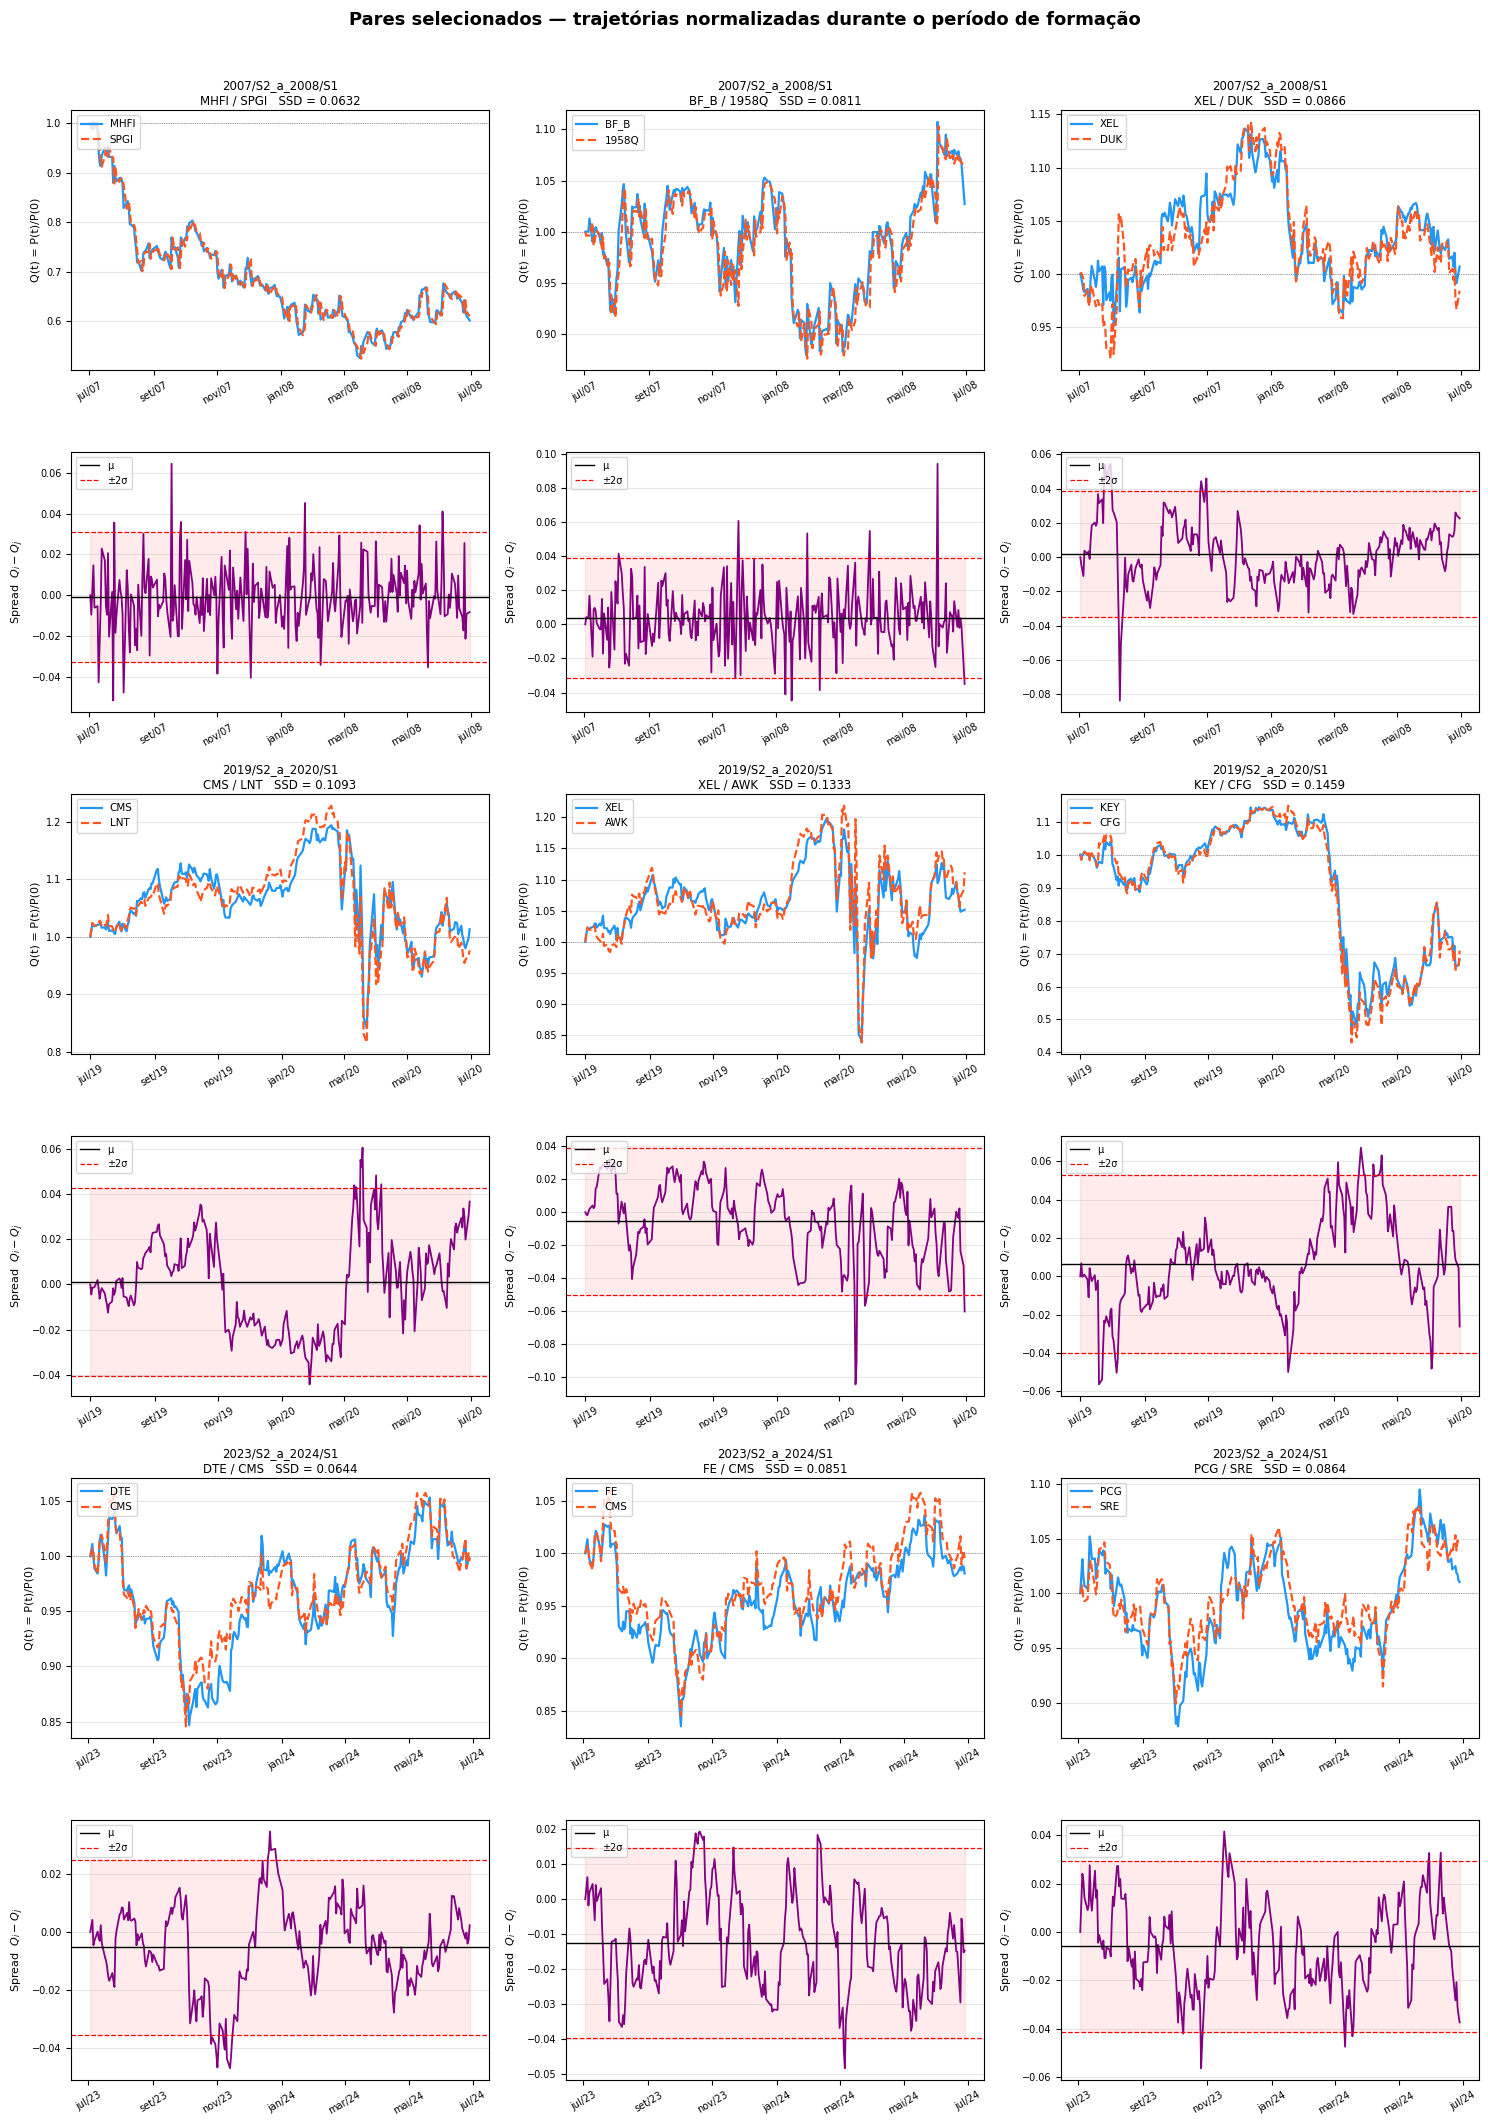

Salvo em: ../data_bases/pares_visualizacao.png


In [27]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ── Configuração ──────────────────────────────────────────────────────────────
JANELAS_ALVO = [
    "2007/S2_a_2008/S1",   # pré-crise financeira
    "2019/S2_a_2020/S1",   # COVID
    "2023/S2_a_2024/S1",   # recente
]
N_PARES = 3          # quantos pares mostrar por janela
SSD_MIN = 1e-5       # ignora pares com SSD ≈ 0 (classes do mesmo papel)

# ── Layout: 2 linhas por janela (preços + spread), N_PARES colunas ────────────
n_rows = len(JANELAS_ALVO) * 2
fig, axes = plt.subplots(n_rows, N_PARES, figsize=(5 * N_PARES, 3.5 * n_rows))
fig.suptitle(
    "Pares selecionados — trajetórias normalizadas durante o período de formação",
    fontsize=13, fontweight="bold", y=1.01,
)

CORES = ["#2196F3", "#FF5722"]   # azul / laranja para os dois ativos

for bloco, janela_id in enumerate(JANELAS_ALVO):
    row_q = bloco * 2       # linha dos preços normalizados
    row_s = bloco * 2 + 1  # linha do spread

    # Pares da janela, filtrando SSD triviais
    pares_janela = (
        pares_df[
            (pares_df["janela"] == janela_id) &
            (pares_df["ssd"] >= SSD_MIN)
        ]
        .head(N_PARES)
    )
    if pares_janela.empty:
        continue

    # Reconstruir Q para essa janela
    periodos = [pares_janela.iloc[0]["formacao_inicio"],
                pares_janela.iloc[0]["formacao_fim"]]
    mask   = df["period"].isin(periodos)
    precos = filtrar_ativos_completos(df.loc[mask, colunas_preco])
    Q      = normalizar_precos(precos)

    for col, (_, par) in enumerate(pares_janela.iterrows()):
        a1, a2 = par["ativo1"], par["ativo2"]

        # Pular se algum ticker não tem dado completo nessa janela
        if a1 not in Q.columns or a2 not in Q.columns:
            for ax in [axes[row_q, col], axes[row_s, col]]:
                ax.axis("off")
            continue

        ax_q = axes[row_q, col]
        ax_s = axes[row_s, col]
        mu, sigma = par["spread_media"], par["spread_desvio"]

        # ── Painel superior: Q_i(t) e Q_j(t) ─────────────────────────────
        ax_q.plot(Q.index, Q[a1], color=CORES[0], lw=1.6, label=a1)
        ax_q.plot(Q.index, Q[a2], color=CORES[1], lw=1.6, ls="--", label=a2)
        ax_q.axhline(1, color="gray", lw=0.6, ls=":")
        ax_q.set_title(
            f"{janela_id}\n{a1} / {a2}   SSD = {par['ssd']:.4f}",
            fontsize=8.5, pad=4,
        )
        ax_q.set_ylabel("Q(t) = P(t)/P(0)", fontsize=8)
        ax_q.legend(fontsize=7.5, loc="upper left")
        ax_q.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y"))
        ax_q.tick_params(axis="x", rotation=30, labelsize=7)
        ax_q.tick_params(axis="y", labelsize=7)
        ax_q.grid(axis="y", alpha=0.3)

        # ── Painel inferior: spread e banda ±2σ ───────────────────────────
        spread = Q[a1] - Q[a2]
        ax_s.plot(spread.index, spread, color="purple", lw=1.3)
        ax_s.axhline(mu,             color="black", lw=1.0, ls="-",  label="μ")
        ax_s.axhline(mu + 2 * sigma, color="red",   lw=0.9, ls="--", label="±2σ")
        ax_s.axhline(mu - 2 * sigma, color="red",   lw=0.9, ls="--")
        ax_s.fill_between(spread.index,
                           mu - 2 * sigma, mu + 2 * sigma,
                           alpha=0.08, color="red")
        ax_s.set_ylabel("Spread  $Q_i - Q_j$", fontsize=8)
        ax_s.legend(fontsize=7, loc="upper left")
        ax_s.xaxis.set_major_formatter(mdates.DateFormatter("%b/%y"))
        ax_s.tick_params(axis="x", rotation=30, labelsize=7)
        ax_s.tick_params(axis="y", labelsize=7)
        ax_s.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig("../data_bases/pares_visualizacao.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo em: ../data_bases/pares_visualizacao.png")